In [2]:
from bpd.io import load_dataset
import jax.numpy as jnp
from jax import jit
from bpd.prior import ellip_prior_e1e2
import jax.scipy as jsp

from jax import Array, grad, vmap
# from jax.numpy.linalg import norm
from jax.scipy import stats

from functools import partial

from jax import random

import jax 
from bpd.utils import uniform_logpdf

import matplotlib.pyplot as plt
from bpd.chains import run_inference_nuts

In [3]:

from bpd.sample import sample_ellip_prior
from bpd.shear import scalar_shear_transformation, shear_transformation

from bpd.shear import (
    inv_shear_func1,
    inv_shear_func2,
    inv_shear_transformation,
)

eta_inv_fnc1 = lambda eta: eta2g(eta)[0]
eta_inv_fnc2 = lambda eta: eta2g(eta)[1]

grad_fnc1 = grad(eta_inv_fnc1)
grad_fnc2 = grad(eta_inv_fnc2)


_grad_shear_fnc1 = vmap(
    vmap(grad(inv_shear_func1), in_axes=(0, None)), in_axes=(0, None)
)
_grad_shear_fnc2 = vmap(
    vmap(grad(inv_shear_func2), in_axes=(0, None)), in_axes=(0, None)
)

# already vmapped once
_inv_shear_trans = vmap(inv_shear_transformation, in_axes=(0, None))

In [107]:


def eta2g(eta: Array):
    assert eta.shape == (2,)
    eta1 = eta[0]
    eta2 = eta[1]
    abseta = jnp.sqrt(eta1**2 + eta2**2)
    g1 = eta1 * jnp.tanh(0.5 * abseta) / abseta
    g2 = eta2 * jnp.tanh(0.5 * abseta) / abseta
    return jnp.array([g1, g2])


def g2eta(g: Array):
    assert g.shape == (2,)
    g1 = g[0]
    g2 = g[1]
    absg = jnp.sqrt(g1**2 + g2**2)
    eta1 = g1 * jnp.arctanh(absg) * 2 / absg
    eta2 = g2 * jnp.arctanh(absg) * 2 / absg
    return jnp.array([eta1, eta2])


def sample_noisy_eta(rng_key, *, g, sigma_e: float, sigma_m: float, n: int = 1):
    k1, k2 = random.split(rng_key)
    es = sample_ellip_prior(k1, sigma_e, n)
    essh = shear_transformation(es, g)
    etas = vmap(g2eta)(essh)
    noisy_etas = etas.reshape(n, 2) + random.normal(k2, shape=(n, 2)) * sigma_m
    return noisy_etas, etas


def eta_target(eta, *, data, sigma_e: float, sigma_m: float):
    neta = data
    llike = stats.norm.logpdf(neta, loc=eta, scale=sigma_m).sum()

    e1e2 = eta2g(eta)
    lprior1 = jnp.log(ellip_prior_e1e2(e1e2, sigma_e))

    grad1 = grad_fnc1(eta)
    grad2 = grad_fnc2(eta)
    prior2 = jnp.abs(grad1[..., 0] * grad2[..., 1] - grad1[..., 1] * grad2[..., 0])
    lprior2 = jnp.log(prior2)

    return llike + lprior1 + lprior2

def ellip_prior_e1e2_calibrated(e1e2, *, sigma, m , 
                                c=0.0,
                               ):
    x = (e1e2 - c) / (1+m)
    return (1+m)**-1 * ellip_prior_e1e2(x, sigma=sigma)



def shear_eta_target_new(params, *, data, sigma_e_int: float,):
    assert data.ndim == 3 and data.shape[2] == 2
    etas = data

    g = params['g']
    sigma_e = params['sigma_e']
    m = params['m']

    # P(eta' | alpha, g) = P(eps | alpha) * (del eps' / del eta') * (del eps / del eps')
    # first jacobian on eta cancels between num and denom so we ignore it.
    eps_sheared = vmap(vmap(eta2g))(etas)
    eps = _inv_shear_trans(eps_sheared, g)
    num1 = jnp.log(ellip_prior_e1e2_calibrated(eps, sigma=sigma_e, m=m))

    grad_eps1 = _grad_shear_fnc1(eps_sheared, g)
    grad_eps2 = _grad_shear_fnc2(eps_sheared, g)
    jac = jnp.abs(
        grad_eps1[..., 0] * grad_eps2[..., 1] - grad_eps1[..., 1] * grad_eps2[..., 0]
    )
    num2 = jnp.log(jac)

    num = num1 + num2

    # now denom P0(eta') = P0(eps') * (del eps' / del eta')
    denom = jnp.log(ellip_prior_e1e2(eps_sheared, sigma_e_int))

    # ratio
    ratio = jsp.special.logsumexp(num - denom, axis=-1)
    loglike = ratio.sum()

    # prior on shear
    g_mag = jnp.sqrt(g[0] ** 2 + g[1] ** 2)
    logprior_g = uniform_logpdf(g_mag, 0.0, 1.0) + jnp.log(1 / (2 * jnp.pi))

    # prior on other
    logprior_m = stats.norm.logpdf(m, loc=0.0, scale=0.01)
    # logprior_m = uniform_logpdf(m, -0.9, 0.9)
    logprior_sigma = uniform_logpdf(sigma_e, 0.01, 0.5)
    # logprior_sigma = stats.norm.logpdf(sigma_e, loc=0.02, scale=1e-5)
    
    return loglike + logprior_g+ logprior_m + logprior_sigma

In [108]:
# # use a modified version of BA2014 distribution for true prior, add m,c which are inferred jointly
# # with shear



# def true_ellip_logprior(e_post, g, *, sigma_e: float, 
#                         m:float,
#                         # c:float
#                        ):
#     """Implementation of GB's true prior on interim posterior samples of ellipticities."""

#     # jacobian of inverse shear transformation
#     grad1 = _grad_fnc1(e_post, g)
#     grad2 = _grad_fnc2(e_post, g)
#     absjacdet = jnp.abs(grad1[..., 0] * grad2[..., 1] - grad1[..., 1] * grad2[..., 0])

#     # true prior on unsheared ellipticity
#     e_post_unsheared = _inv_shear_trans(e_post, g)
#     prior_val = ellip_prior_e1e2_calibrated(e_post_unsheared, sigma=sigma_e, m=m, 
#                                             # c=c
#                                            )

#     return jnp.log(prior_val) + jnp.log(absjacdet)

# def shear_loglikelihood(
#     g,
#     post_params,
#     *,
#     logprior,
#     interim_logprior
# ):
#     """Shear Likelihood implementation of Schneider et al. 2014."""
#     num = logprior(post_params, g)
#     denom = interim_logprior(post_params)
#     ratio = jsp.special.logsumexp(num - denom, axis=-1)
#     return ratio.sum()

# def logtarget(
#     params,
#     data,
#     *,
#     sigma_e_int: float,
# ):
#     g = params['g']
#     sigma_e = params['sigma_e']
#     m = params['m']
#     # c = params['c']

#     _logprior = lambda e, g: true_ellip_logprior(e, g, sigma_e=sigma_e, m=m, 
#                                                  # c=c
#                                                 )
#     _interim_logprior = lambda e: jnp.log(ellip_prior_e1e2(e, sigma=sigma_e_int))

#     loglike = shear_loglikelihood(g, e1e2, logprior=_logprior, interim_logprior=_interim_logprior)

#     g_mag = jnp.sqrt(g[0] ** 2 + g[1] ** 2)
#     logprior_g = uniform_logpdf(g_mag, 0.0, 1.0) + jnp.log(1 / (2 * jnp.pi))
#     # logprior_m = uniform_logpdf(m, -0.5, 0.5)
#     logprior_m = stats.norm.logpdf(m, loc=0.0, scale=0.1)
#     # logprior_c = uniform_logpdf(m, -0.5, 0.5)
#     logprior_sigma = uniform_logpdf(sigma_e, 1e-4, 1.0)

#     logprior = logprior_g + logprior_m + logprior_sigma #+ logprior_c

#     return loglike + logprior

In [126]:
import numpy as np 
e1 = np.linspace(-1.0, 1.0, 10000)
e2 = np.zeros_like(e1)
e1e2 = np.stack([e1, e2], axis=-1)
e1e2.shape

(10000, 2)

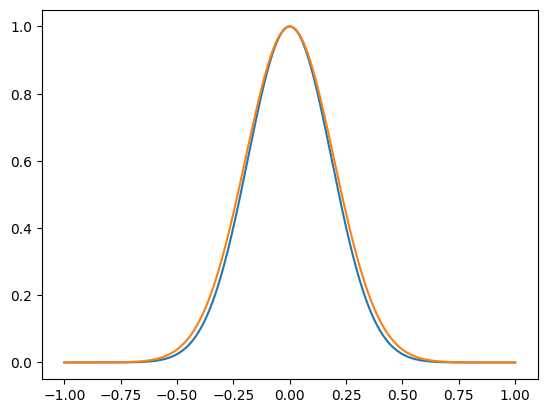

In [133]:
dist1 = ellip_prior_e1e2_calibrated(e1e2, sigma=0.2, m=0.0)
dist2 = ellip_prior_e1e2_calibrated(e1e2, sigma=0.1, m=1.0)

plt.plot(e1,dist1 / dist1.max())
plt.plot(e1, dist2 / dist2.max())

In [149]:
sigma_e=0.2
sigma_m=0.001
n_gals=100000
sigma_e_int=0.3

In [150]:
k = random.key(42)
k1, k2, k3  = random.split(k, 3)


In [151]:
netas, etas = sample_noisy_eta(
    k1, g=jnp.array([0.02,0.0]), sigma_e=sigma_e, sigma_m=sigma_m, n=n_gals)
etas.shape

(100000, 2)

In [152]:

# run phase 1
target1 = partial(eta_target, sigma_e=sigma_e_int, sigma_m=sigma_m)
pipe1 = partial(
    run_inference_nuts,
    logtarget=target1,
    n_samples=300,
    initial_step_size=0.01,
    max_num_doublings=2,
)
pipe1 = vmap(jit(pipe1))
k2s = random.split(k2, n_gals)
eta_samples = pipe1(k2s, netas, etas)
eta_samples.shape

(100000, 300, 2)

(array([1.33290471e-04, 1.77720628e-04, 1.77720628e-03, 7.24211558e-03,
        3.17675622e-02, 9.77463453e-02, 2.86663373e-01, 6.13491607e-01,
        9.49516884e-01, 1.03726644e+00, 7.78860651e-01, 4.10356929e-01,
        1.60881598e-01, 5.00283567e-02, 1.28847455e-02, 3.06568083e-03,
        7.55312668e-04, 2.66580942e-04, 8.88603139e-05, 0.00000000e+00,
        4.44301569e-05]),
 array([-2.03263547, -1.80756312, -1.58249077, -1.35741841, -1.13234606,
        -0.9072737 , -0.68220135, -0.457129  , -0.23205664, -0.00698429,
         0.21808806,  0.44316042,  0.66823277,  0.89330513,  1.11837748,
         1.34344983,  1.56852219,  1.79359454,  2.01866689,  2.24373925,
         2.4688116 ,  2.69388396]),
 [<matplotlib.patches.Polygon at 0x7f91e648a270>])

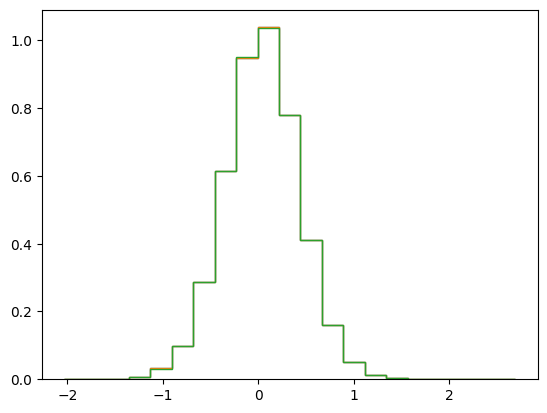

In [153]:
_,bins,_= plt.hist(eta_samples[...,0].ravel(),bins=21,histtype='step',density=True)
plt.hist(netas[...,0].ravel(),bins=bins,histtype='step',density=True)
plt.hist(etas[...,0].ravel(),bins=bins,histtype='step',density=True)

In [154]:
# scatter plot 

In [155]:
# run phase 2
target2 = partial(shear_eta_target_new, sigma_e_int=sigma_e_int)
pipe2 = partial(
    run_inference_nuts,
    logtarget=target2,
    n_samples=500,
    n_warmup_steps=500,
    initial_step_size=0.01,
    max_num_doublings=5,
)
pipe2 = jit(pipe2)

In [156]:
samples = pipe2(k3, eta_samples, {'g':jnp.array([0.02,0.0]), 'sigma_e':sigma_e, 'm':0.0})

In [157]:
samples.keys()

dict_keys(['g', 'm', 'sigma_e'])

In [158]:
samples['g'].shape

(500, 2)

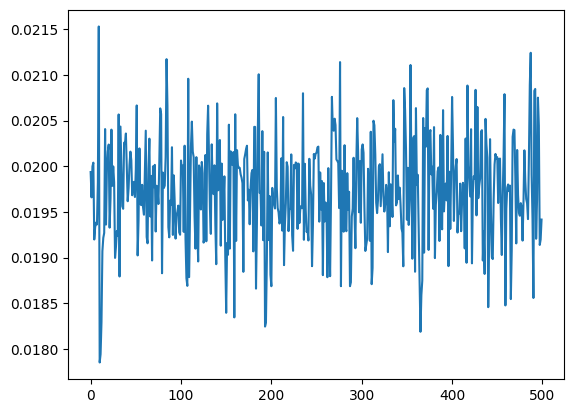

In [159]:
plt.plot(samples['g'][:, 0])

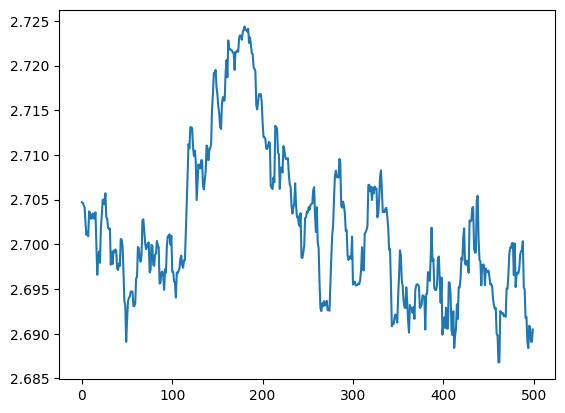

In [160]:
plt.plot(samples['m'])

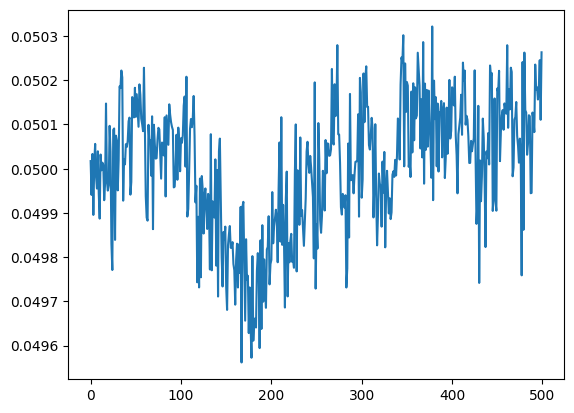

In [161]:
plt.plot(samples['sigma_e'])

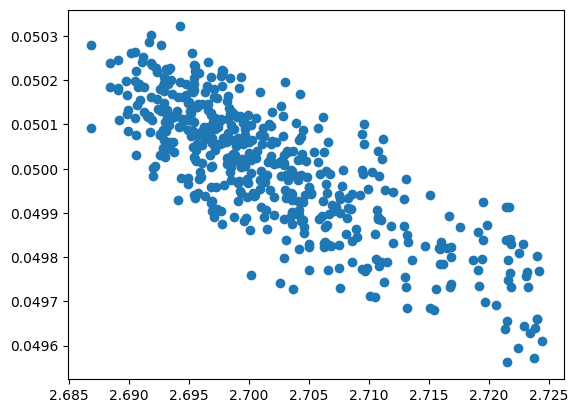

In [162]:
plt.scatter(samples['m'], samples['sigma_e'])

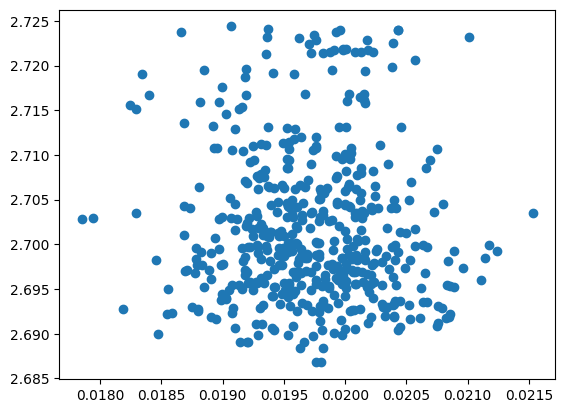

In [163]:
plt.scatter(samples['g'][:,0], samples['m'])